# Dyna maze

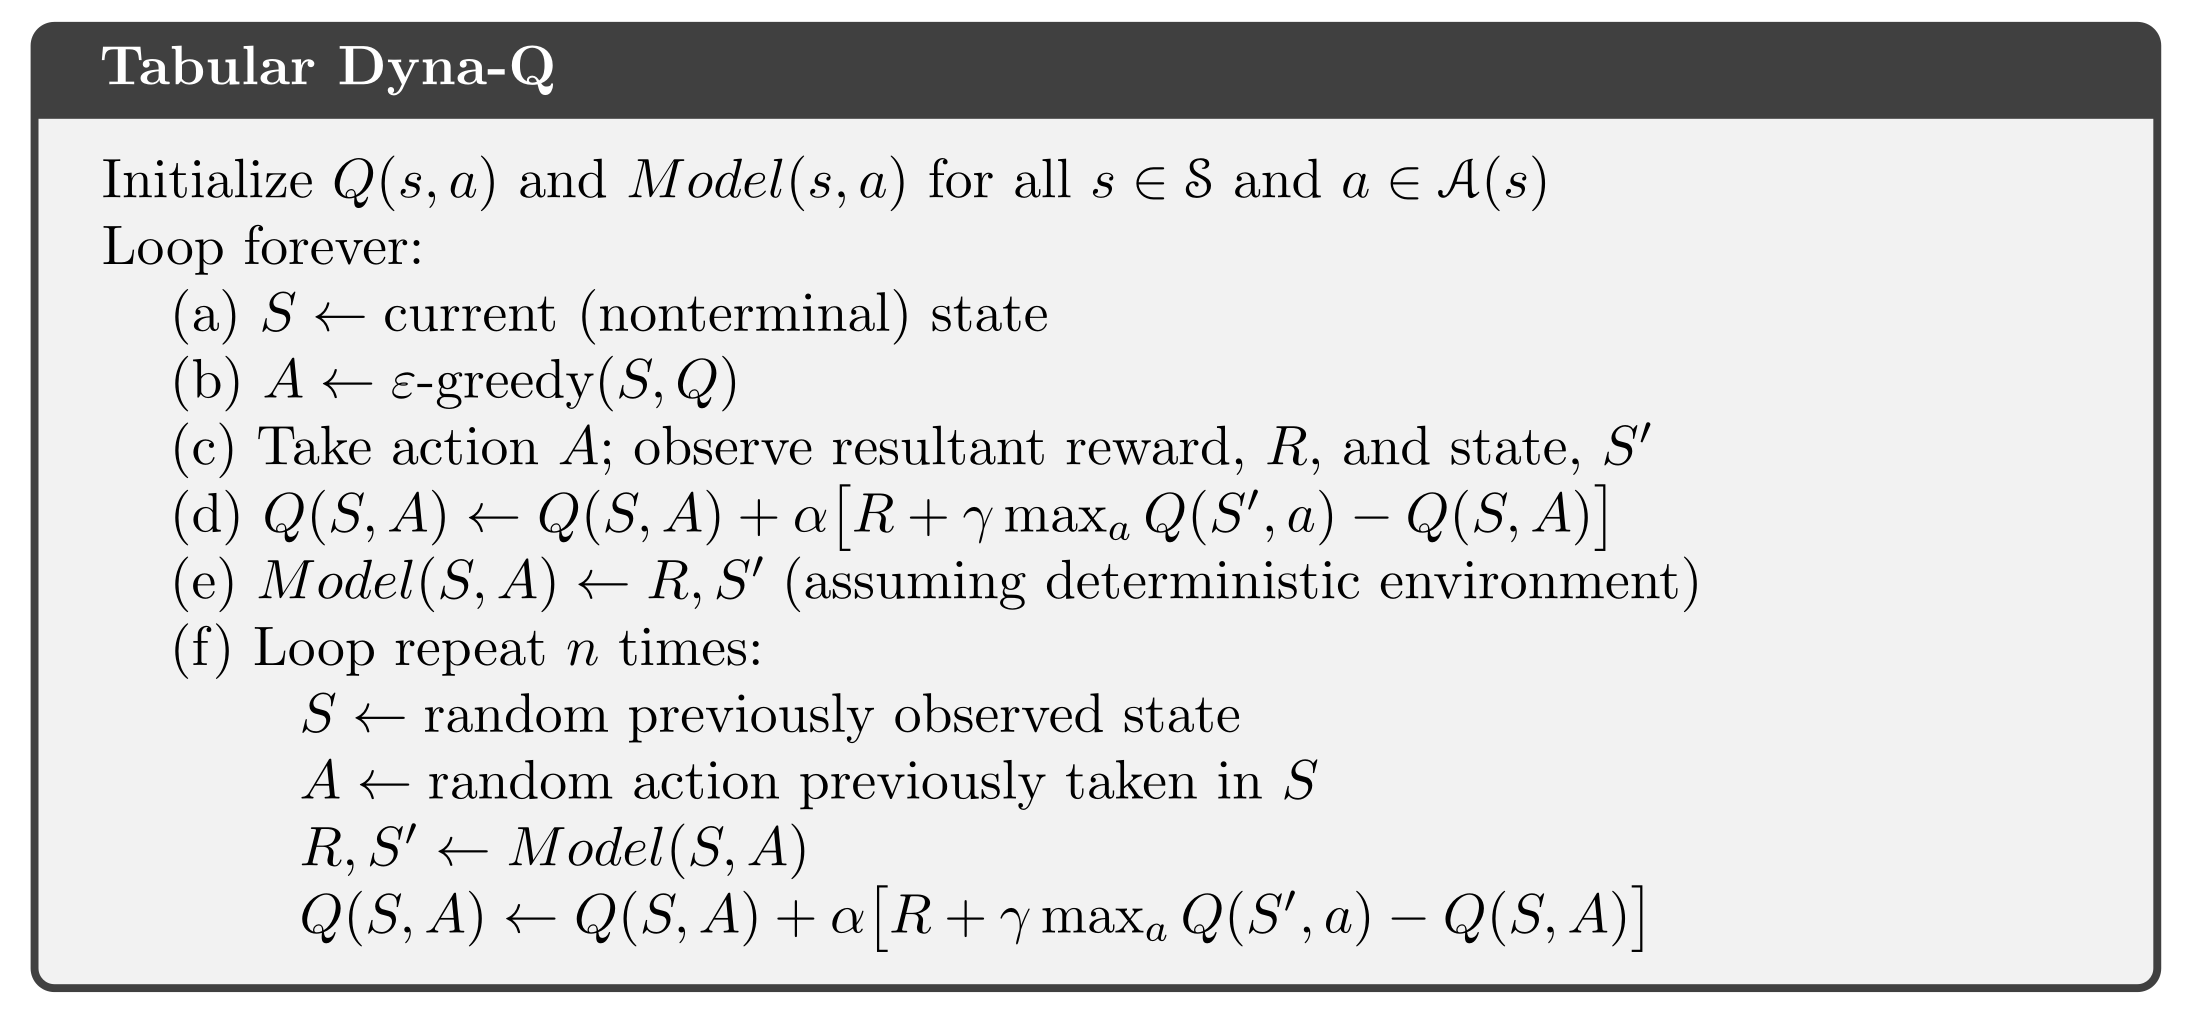

In [ ]:
from collections import defaultdict
import random
import matplotlib.pyplot as plt

In [ ]:
class Maze:
    def __init__(self, nrow=6, ncol=9, start=(2,0), goal=(0,8), blocks = [(1,2), (2,2), (3,2), (4, 5), (0, 7), (1, 7), (2,)]):
        self.nrow = nrow
        self.ncol = ncol
        self.start = start
        self.goal = goal
        self.blocks = blocks
        def transition(row, col, act):
            # 0 up, 1 right, 2 down, 3 left
            newrow, newcol = row, col
            if act == 0:
                newrow -= 1
            if act == 1:
                newcol += 1
            if act == 2:
                newrow +=1
            if act == 3:
                newcol -= 1
            if (newrow, newcol) in self.blocks or newrow < 0 or newrow >= self.nrow or newcol < 0 or newcol >= self.ncol:
                newrow, newcol = row, col # if new state is invalid, reset to state before step
            return newrow, newcol
        self.transition = transition
    
    def reset(self):
        self.row = self.start[0]
        self.col = self.start[1]
        return (self.row, self.col), {}

    def step(self, action):
        # action is 0, 1, 2, 3
        newrow, newcol = self.transition(self.row, self.col, action)
        self.row, self.col = newrow, newcol
        rew = 1 if (newrow, newcol) == self.goal else 0
        terminated = (self.row, self.col) == self.goal
        truncated = False
        return (self.row, self.col), rew, terminated, truncated, {} # obs, reward, terminated, truncated, info

In [15]:
class Qtable(defaultdict):
    def __init__(self, eps = 0.1):
        super().__init__(float) # initialized to 0.0 for non-existing keys
        self.eps = eps

    def epsgreedy(self, S):
        # S = (row, col)
        # Q indexed by (S, action)
        if random.random() < self.eps:
            return random.sample([0,1,2,3], 1)[0]
        else:
            # qvalues = [self[(S, a)] for a in [0, 1, 2, 3]]
            qvalues = [self[(S, a)] if (S, a) in self.keys() else 0.0 for a in [0, 1, 2, 3]] # be careful not to access self[key] directly, as this will initialize it
            return qvalues.index(max(qvalues))
    
    def max_a(self, S):
        # qvalues = [self[(S, a)] for a in [0, 1, 2, 3]]
        qvalues = [self[(S, a)] if (S, a) in self.keys() else 0.0 for a in [0, 1, 2, 3]]
        return max(qvalues)

In [16]:
class Model(dict):
    def __init__(self):
        super().__init__()
    
    def sample(self):
        S = random.sample(list(self.keys()), 1)[0]
        A = self[S]
        return S, A

In [ ]:
class DynaQ():
    def __init__(self, env, alpha = 0.1, gamma = 0.95, eps = 0.1):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.eps = eps

        # Initialize Q(s, a) and Model(s, a) for all s \in S and a \in A(s)
        self.Q = Qtable(eps)
        self.model = Model()

        self.steps_per_episode = []

    def train(self, n_episodes, n_planning):
        for iep in range(n_episodes):
            steps = 0
            done = False
            S, info = self.env.reset()
            while not done:

                # Loop forever:
                # Acting:
                # (a) S <- current (nonterminal) state
                S = (self.env.row, self.env.col)

                # (b) A <- \eps-greedy(S, Q)
                A = self.Q.epsgreedy(S)

                # (c) Take action A; observe resultant reward, R, and state, S'
                S_prime, R, terminated, truncated, info = self.env.step(A)
                done = terminated or truncated
                steps += 1

                # Direct reinforcement learning:
                # (d) Q(S, A) <- Q(S, A) + \alpha(R + \gamma max_a Q(S', a) - Q(S, A))
                self.Q[(S, A)] = self.Q[(S, A)] + self.alpha * (R + self.gamma * self.Q.max_a(S_prime) - self.Q[(S, A)])

                # Model learning:
                # (e) Model(S, A) <- R, S' (assuming deterministic environment)
                self.model[(S, A)] = (R, S_prime)
                
                # Model planning:
                # (f) Loop repeat n times:
                for iplan in range(n_planning):
                    # S <- random previously observed state
                    # A <- random action previously taken in s
                    S, A = random.sample(list(self.Q.keys()), 1)[0]
                    
                    # R,S' <- Model(S, A)
                    R, S_prime = self.model[(S, A)]

                    # Q(S, A) <- Q(S, A) + \alpha(R + \gamma max_a Q(S', a) - Q(S, A))
                    self.Q[(S, A)] = self.Q[(S, A)] + self.alpha * (R + self.gamma * self.Q.max_a(S_prime) - self.Q[(S, A)])

            self.steps_per_episode.append(steps)

In [30]:
dyna0 = DynaQ(Maze())
dyna5 = DynaQ(Maze())
dyna50 = DynaQ(Maze())
dyna0.train(n_episodes=50, n_planning=0)
dyna5.train(n_episodes=50, n_planning=5)
dyna50.train(n_episodes=50, n_planning=50)

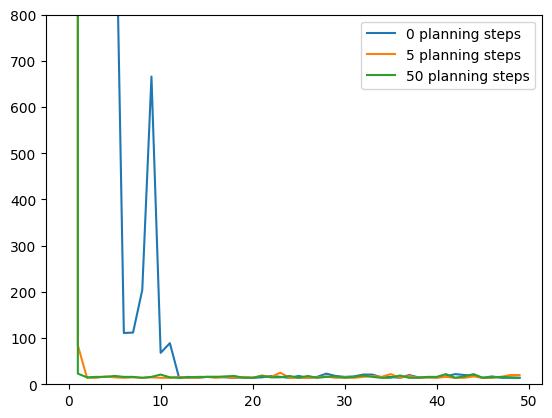

In [ ]:
plt.plot(dyna0.steps_per_episode)
plt.plot(dyna5.steps_per_episode)
plt.plot(dyna50.steps_per_episode)
plt.ylim((0, 800))
plt.legend(["0 planning steps", "5 planning steps", "50 planning steps"])
plt.show()

In [ ]:
# Problems:
# - slow
# - we don't use the model.sample() method
# - do I really need to subclass defaultdict()? I'm not accessing non-initialized values.